# Lift-Splat-Shoot 训练主路径逐层下钻笔记

这份笔记按仓库里的真实训练流程展开：

`main.py -> src/train.py -> src/data.py -> src/models.py -> src/tools.py -> src/explore.py`

目标有两个：

1. 从训练入口一路追到最底层，完整解释 LSS 在 nuScenes 上做了什么。
2. 每个关键步骤都配一个独立、可运行的小示例，便于验证形状、坐标系和聚合逻辑。

阅读建议：

- 先看每节开头的“对应源码位置”，建立代码定位感。
- 再运行示例单元，确认自己对张量形状和几何过程的理解。
- 最后用第 20 节的一次最小前向反向闭环做总验收。

## LSS 总览：Lift、Splat、Shoot 分别在做什么

LSS 全称是 Lift-Splat-Shoot。它的核心思想不是直接在图像平面上做多相机融合，而是把多相机图像先变成一个统一的 3D / BEV 表达，再在这个统一坐标系里做感知与决策。

可以先把它理解成三步：

### 1. Lift

Lift 的意思是“抬升”。

输入原本只是 2D 图像特征，每个像素只有 `(u, v)`，缺少深度信息，所以还不能直接知道这个像素在真实三维空间里对应哪里。LSS 在这一步会：

- 先用相机编码器提取每张图像的语义特征
- 对每个像素预测一个离散深度分布
- 把 2D 特征沿深度维复制并加权展开
- 得到一个 frustum feature，也就是“像素平面 × 深度层”的 3D 特征体

直观上看，Lift 做的是：

> 把“图像上的一个点”扩展成“空间中一条视锥上的一串候选点”。

在本仓库里，Lift 主要对应：

- `create_frustum`
- `CamEncode.get_depth_feat`
- `get_geometry`

### 2. Splat

Splat 的意思是“泼洒”或“投放”。

经过 Lift 以后，每个相机都得到了一堆带几何位置的 frustum 特征点。Splat 这一步会把这些点统一投到 BEV 网格里：

- 先把每个 frustum 点变到 ego 坐标系
- 再把连续坐标离散到 BEV 体素索引
- 同一个体素里可能会落入来自不同相机、不同深度层的多个点
- 用排序 + `cumsum trick` 把这些点的特征聚合起来
- 最后写回成稠密的 BEV 特征图

直观上看，Splat 做的是：

> 把各个相机看到的局部证据，汇总到同一个俯视图坐标系中。

这一步是多相机融合真正发生的地方。在本仓库里，Splat 主要对应：

- `voxel_pooling`
- `cumsum_trick`
- `QuickCumsum`

### 3. Shoot

Shoot 的意思可以理解成“在 BEV 表达上做下游任务”。

原论文里，Shoot 不只是做 BEV 分割，还包括把候选轨迹“射”到代价图上做运动规划评分。所以从论文视角看，Shoot 表示：

- 已经得到了统一的 BEV 场景表示
- 接下来可以在这个表示上做检测、分割、地图预测、轨迹评估等任务

而在这个仓库里，给出的主任务是 **BEV 车辆占据分割**，所以这里的 Shoot 具体表现为：

- 把 splat 之后的 BEV 特征送入 `BevEncode`
- 输出 `B x 1 x X x Y` 的 logits
- 再和 `binimg` 标签计算 BCE 和 IoU

也就是说，这个仓库里的 Shoot 更接近：

> 在已经对齐好的 BEV 特征图上，完成最终的语义预测。

### 一句话串起来

LSS 的整条主线可以概括为：

1. **Lift**：把 2D 图像特征沿深度抬升成 3D frustum 特征。
2. **Splat**：把多相机的 3D 特征投到统一的 BEV 网格并聚合。
3. **Shoot**：在 BEV 特征图上完成下游任务输出，这个仓库里是车辆占据分割。

如果只记一句最核心的话，可以记成：

> LSS 不是先把相机结果各自做完再融合，而是先通过几何把多相机信息对齐到 BEV，再在 BEV 上统一做预测。

下面整本笔记就是沿着这条主线，从训练入口一步一步拆到最底层。

In [1]:
import os
import math
import random
from pathlib import Path

os.environ.pop('MPLBACKEND', None)

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
from IPython.display import display

try:
    import torchvision
except Exception as exc:
    torchvision = None
    print('torchvision 导入失败:', exc)

try:
    import efficientnet_pytorch
except Exception as exc:
    efficientnet_pytorch = None
    print('efficientnet_pytorch 导入失败:', exc)

try:
    import nuscenes
except Exception as exc:
    nuscenes = None
    print('nuscenes-devkit 导入失败:', exc)

seed = 13
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

project_root = Path.cwd()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print('project_root =', project_root)
print('device =', device)
print('torch =', torch.__version__)
print('torchvision =', getattr(torchvision, '__version__', 'not-installed'))
print('efficientnet_pytorch =', getattr(efficientnet_pytorch, '__version__', 'not-installed'))
print('nuscenes-devkit =', getattr(nuscenes, '__version__', 'not-installed'))

for path in sorted(project_root.iterdir()):
    print(path.name)


def to_uint8_image(arr):
    arr = np.asarray(arr, dtype=np.float32)
    arr = arr - arr.min()
    if arr.max() > 0:
        arr = arr / arr.max()
    arr = (arr * 255).clip(0, 255).astype(np.uint8)
    if arr.ndim == 2:
        return Image.fromarray(arr)
    return Image.fromarray(arr, mode='RGB')

torchvision 导入失败: operator torchvision::nms does not exist
project_root = /home/zhangjinrui/DockerDisk/code_files/代码/Data_Processing/python/RL/IL
device = cuda
torch = 2.10.0+cu128
torchvision = not-installed
efficientnet_pytorch = 0.7.0
nuscenes-devkit = not-installed
0_世界模型方案.ipynb
1_VAE.ipynb
2_diffusion.ipynb
3_DDPM原理及代码详解.ipynb
4_dits.ipynb
5_deformable_attention.ipynb
6_detr.ipynb
7_deformable_detr.ipynb
8_lss_training_flow.ipynb


## 1. 环境与项目入口检查

对应源码位置：`main.py`

仓库的真实命令入口非常薄，只做了一件事：把 `train`、`eval_model_iou`、`viz_model_preds`、`lidar_check`、`cumsum_check` 这些函数暴露给命令行。也就是说，真正的训练逻辑都在 `src/train.py` 里。

入口关系可以概括成：

```text
python main.py train mini --dataroot=...
    -> main.py / Fire
    -> src.train.train(...)
    -> compile_data(...)
    -> compile_model(...)
    -> optimizer / loss / logging / validation
```

下面这段代码不依赖真实数据集，只负责检查依赖、设备、项目目录和调用图。

In [2]:
call_graph = {
    'main.py': ['train', 'eval_model_iou', 'viz_model_preds', 'lidar_check', 'cumsum_check'],
    'train': ['compile_data', 'compile_model', 'SimpleLoss', 'optimizer.step', 'get_val_info'],
    'compile_data': ['NuscData', 'SegmentationData', 'DataLoader'],
    'compile_model': ['LiftSplatShoot'],
    'LiftSplatShoot.forward': ['get_voxels', 'BevEncode'],
    'get_voxels': ['get_geometry', 'get_cam_feats', 'voxel_pooling'],
}

for node, children in call_graph.items():
    print(f'{node:>22} -> {children}')

               main.py -> ['train', 'eval_model_iou', 'viz_model_preds', 'lidar_check', 'cumsum_check']
                 train -> ['compile_data', 'compile_model', 'SimpleLoss', 'optimizer.step', 'get_val_info']
          compile_data -> ['NuscData', 'SegmentationData', 'DataLoader']
         compile_model -> ['LiftSplatShoot']
LiftSplatShoot.forward -> ['get_voxels', 'BevEncode']
            get_voxels -> ['get_geometry', 'get_cam_feats', 'voxel_pooling']


## 2. 训练配置与 BEV 网格参数可视化

对应源码位置：`src/train.py`, `src/tools.py::gen_dx_bx`

训练函数先构造两份核心配置：

- `grid_conf`：控制 BEV 网格和深度离散。
- `data_aug_conf`：控制图像尺寸、增强和使用多少相机。

其中：

- `xbound=[xmin, xmax, dx]`
- `ybound=[ymin, ymax, dy]`
- `zbound=[zmin, zmax, dz]`
- `dbound=[dmin, dmax, dd]`

它们最终决定：

- BEV 网格分辨率
- 高度切片数量
- frustum 深度层数
- 整个模型的空间感受范围

In [3]:
def gen_dx_bx_local(xbound, ybound, zbound):
    dx = torch.tensor([xbound[2], ybound[2], zbound[2]], dtype=torch.float32)
    bx = torch.tensor([
        xbound[0] + xbound[2] / 2.0,
        ybound[0] + ybound[2] / 2.0,
        zbound[0] + zbound[2] / 2.0,
    ], dtype=torch.float32)
    nx = torch.tensor([
        int((xbound[1] - xbound[0]) / xbound[2]),
        int((ybound[1] - ybound[0]) / ybound[2]),
        int((zbound[1] - zbound[0]) / zbound[2]),
    ], dtype=torch.long)
    return dx, bx, nx


grid_conf = {
    'xbound': [-50.0, 50.0, 0.5],
    'ybound': [-50.0, 50.0, 0.5],
    'zbound': [-10.0, 10.0, 20.0],
    'dbound': [4.0, 45.0, 1.0],
}

data_aug_conf = {
    'resize_lim': (0.193, 0.225),
    'final_dim': (128, 352),
    'rot_lim': (-5.4, 5.4),
    'H': 900,
    'W': 1600,
    'rand_flip': True,
    'bot_pct_lim': (0.0, 0.22),
    'cams': ['CAM_FRONT_LEFT', 'CAM_FRONT', 'CAM_FRONT_RIGHT', 'CAM_BACK_LEFT', 'CAM_BACK', 'CAM_BACK_RIGHT'],
    'Ncams': 5,
}

dx, bx, nx = gen_dx_bx_local(grid_conf['xbound'], grid_conf['ybound'], grid_conf['zbound'])
D = int((grid_conf['dbound'][1] - grid_conf['dbound'][0]) / grid_conf['dbound'][2])
print('dx =', dx)
print('bx =', bx)
print('nx =', nx)
print('depth bins D =', D)
print('BEV 范围 X x Y =', nx[0].item(), 'x', nx[1].item())
print('输入图像大小 =', data_aug_conf['final_dim'])

dx = tensor([ 0.5000,  0.5000, 20.0000])
bx = tensor([-49.7500, -49.7500,   0.0000])
nx = tensor([200, 200,   1])
depth bins D = 41
BEV 范围 X x Y = 200 x 200
输入图像大小 = (128, 352)


## 3. DataLoader 输出结构与单批样本解包

对应源码位置：`src/train.py::train`, `src/data.py::SegmentationData.__getitem__`

训练时，每个 batch 被解包成：

- `imgs`: 多相机图像，形状 `B x N x 3 x H x W`
- `rots`: 相机旋转，形状 `B x N x 3 x 3`
- `trans`: 相机平移，形状 `B x N x 3`
- `intrins`: 内参矩阵，形状 `B x N x 3 x 3`
- `post_rots`: 图像增强后的 2D 仿射矩阵扩展到 3D，形状 `B x N x 3 x 3`
- `post_trans`: 图像增强后的平移扩展到 3D，形状 `B x N x 3`
- `binimgs`: BEV 二值标签，形状 `B x 1 x X x Y`

下面先构造一个不依赖真实 nuScenes 数据的 mock batch，专门用来记住这些形状。

In [4]:
B, N, H, W = 2, 5, 128, 352
X, Y = nx[0].item(), nx[1].item()

imgs = torch.randn(B, N, 3, H, W)
rots = torch.eye(3).view(1, 1, 3, 3).repeat(B, N, 1, 1)
trans = torch.randn(B, N, 3)
intrins = torch.eye(3).view(1, 1, 3, 3).repeat(B, N, 1, 1)
post_rots = torch.eye(3).view(1, 1, 3, 3).repeat(B, N, 1, 1)
post_trans = torch.zeros(B, N, 3)
binimgs = torch.randint(0, 2, (B, 1, X, Y)).float()

batch = (imgs, rots, trans, intrins, post_rots, post_trans, binimgs)
for name, tensor in zip(['imgs', 'rots', 'trans', 'intrins', 'post_rots', 'post_trans', 'binimgs'], batch):
    print(f'{name:>10} | shape={tuple(tensor.shape)} | dtype={tensor.dtype} | device={tensor.device}')

      imgs | shape=(2, 5, 3, 128, 352) | dtype=torch.float32 | device=cpu
      rots | shape=(2, 5, 3, 3) | dtype=torch.float32 | device=cpu
     trans | shape=(2, 5, 3) | dtype=torch.float32 | device=cpu
   intrins | shape=(2, 5, 3, 3) | dtype=torch.float32 | device=cpu
 post_rots | shape=(2, 5, 3, 3) | dtype=torch.float32 | device=cpu
post_trans | shape=(2, 5, 3) | dtype=torch.float32 | device=cpu
   binimgs | shape=(2, 1, 200, 200) | dtype=torch.float32 | device=cpu


## 4. 图像增强参数与 post_rot / post_tran 独立示例

对应源码位置：`src/data.py::sample_augmentation`, `src/tools.py::img_transform`

LSS 的一个关键点是：图像真的被做了 resize、crop、flip、rotate，但几何分支不会丢掉这些信息，而是把增强过程编码进 `post_rot` 和 `post_tran`。

后面 `get_geometry` 会先做一次逆变换，把增强后的像素坐标撤回到增强前，然后再用相机内外参回投到 3D。

下面用一张合成网格图演示这个过程。

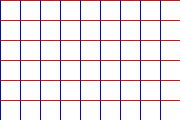

post_rot_2d =
 tensor([[-0.7727,  0.2071],
        [ 0.2071,  0.7727]])
post_tran_2d = tensor([113.3798, -31.2433])
original =
 tensor([[ 40., 100.,  60.],
        [ 50.,  60.,  90.]])
augmented =
 tensor([[92.8229, 48.5290, 85.6503],
        [15.6760, 35.8267, 50.7267]])
recovered =
 tensor([[ 40.0000, 100.0000,  60.0000],
        [ 50.0000,  60.0000,  90.0000]])
max error = 3.814697265625e-06


In [5]:
def get_rot_local(angle_deg):
    angle = math.radians(angle_deg)
    return torch.tensor([
        [math.cos(angle), math.sin(angle)],
        [-math.sin(angle), math.cos(angle)],
    ], dtype=torch.float32)


def make_grid_image(h=120, w=180, step=20):
    img = np.ones((h, w, 3), dtype=np.float32)
    for y in range(0, h, step):
        img[y:y+1, :, :] = np.array([1.0, 0.0, 0.0])
    for x in range(0, w, step):
        img[:, x:x+1, :] = np.array([0.0, 0.0, 1.0])
    return img


def update_post_transform(post_rot, post_tran, resize, crop, flip, rotate_deg):
    post_rot = post_rot * resize
    post_tran = post_tran - torch.tensor(crop[:2], dtype=torch.float32)
    if flip:
        A = torch.tensor([[-1.0, 0.0], [0.0, 1.0]])
        b = torch.tensor([crop[2] - crop[0], 0.0])
        post_rot = A @ post_rot
        post_tran = A @ post_tran + b
    A = get_rot_local(rotate_deg)
    b = torch.tensor([crop[2] - crop[0], crop[3] - crop[1]], dtype=torch.float32) / 2.0
    b = A @ (-b) + b
    post_rot = A @ post_rot
    post_tran = A @ post_tran + b
    return post_rot, post_tran

img = make_grid_image()
resize = 0.8
crop = (10, 15, 130, 95)
flip = True
rotate_deg = 15
post_rot_2d = torch.eye(2)
post_tran_2d = torch.zeros(2)
post_rot_2d, post_tran_2d = update_post_transform(post_rot_2d, post_tran_2d, resize, crop, flip, rotate_deg)

display(to_uint8_image(img))
print('post_rot_2d =\n', post_rot_2d)
print('post_tran_2d =', post_tran_2d)

pts = torch.tensor([[40.0, 50.0], [100.0, 60.0], [60.0, 90.0]]).T
aug_pts = post_rot_2d @ pts + post_tran_2d[:, None]
recovered = torch.inverse(post_rot_2d) @ (aug_pts - post_tran_2d[:, None])
print('original =\n', pts)
print('augmented =\n', aug_pts)
print('recovered =\n', recovered)
print('max error =', (recovered - pts).abs().max().item())

## 5. 相机内参、外参与坐标系变换验证

对应源码位置：`src/tools.py::ego_to_cam`, `src/tools.py::cam_to_ego`

LSS 的几何链路核心是：

1. 先把 ego 坐标系下的点变到相机坐标系。
2. 再用内参矩阵投到像素平面。
3. 在反方向上，用像素坐标和深度恢复回相机系，再乘外参回到 ego 系。

如果记 $K$ 是内参，$R, t$ 是相机到 ego 的外参，则回投的核心形式是：

$$
p_{ego} = R K^{-1} [ud, vd, d]^T + t
$$

下面用一个手写的小矩阵验证正逆过程。

In [6]:
def ego_to_cam_local(points, rot, trans, intrins):
    points = points - trans[:, None]
    points = rot.T @ points
    points = intrins @ points
    points[:2] = points[:2] / points[2:3]
    return points


def cam_to_ego_local(points, rot, trans, intrins):
    points = torch.cat([points[:2] * points[2:3], points[2:3]], dim=0)
    points = torch.inverse(intrins) @ points
    points = rot @ points
    points = points + trans[:, None]
    return points

K = torch.tensor([
    [100.0, 0.0, 50.0],
    [0.0, 100.0, 40.0],
    [0.0, 0.0, 1.0],
])
R = torch.eye(3)
t = torch.tensor([1.0, 2.0, 0.5])
pego = torch.tensor([
    [6.0, 8.0, 10.0],
    [1.0, 2.0, 1.5],
    [5.0, 6.0, 8.0],
]).T
pego = pego.T

pimg = ego_to_cam_local(pego, R, t, K)
pego_recovered = cam_to_ego_local(pimg, R, t, K)
print('ego points =\n', pego)
print('image points with depth =\n', pimg)
print('ego recovered =\n', pego_recovered)
print('max reconstruction error =', (pego - pego_recovered).abs().max().item())

ego points =
 tensor([[ 6.0000,  8.0000, 10.0000],
        [ 1.0000,  2.0000,  1.5000],
        [ 5.0000,  6.0000,  8.0000]])
image points with depth =
 tensor([[161.1111, 177.2727, 170.0000],
        [ 17.7778,  40.0000,  33.3333],
        [  4.5000,   5.5000,   7.5000]])
ego recovered =
 tensor([[ 6.0000,  8.0000, 10.0000],
        [ 1.0000,  2.0000,  1.5000],
        [ 5.0000,  6.0000,  8.0000]])
max reconstruction error = 9.5367431640625e-07


## 6. BEV 网格参数 $dx$、$bx$、$nx$ 的离散化示例

对应源码位置：`src/tools.py::gen_dx_bx`

`gen_dx_bx` 的输出是后续体素化的基础：

- `dx`：每个体素在 `x/y/z` 方向的步长
- `bx`：每个轴上第一个体素中心的位置
- `nx`：每个轴上的格子数

如果把连续坐标映射到体素坐标，代码里实际在做的是：

$$
index = \left\lfloor \frac{coord - (bx - dx / 2)}{dx} \right\rfloor
$$

这里的 `bx - dx/2` 实际上就是网格最小边界。

In [7]:
origin = bx - dx / 2.0
points_xyz = torch.tensor([
    [-49.8, -49.7, 0.0],
    [-10.2, 20.1, 0.0],
    [0.3, 0.2, 0.0],
    [49.1, 49.2, 0.0],
], dtype=torch.float32)
voxel_idx = ((points_xyz - origin) / dx).long()
print('origin =', origin)
print('points =\n', points_xyz)
print('voxel_idx =\n', voxel_idx)
for point, idx in zip(points_xyz, voxel_idx):
    print(f'point {point.tolist()} -> voxel ({idx[0].item()}, {idx[1].item()}, {idx[2].item()})')

origin = tensor([-50., -50., -10.])
points =
 tensor([[-49.8000, -49.7000,   0.0000],
        [-10.2000,  20.1000,   0.0000],
        [  0.3000,   0.2000,   0.0000],
        [ 49.1000,  49.2000,   0.0000]])
voxel_idx =
 tensor([[  0,   0,   0],
        [ 79, 140,   0],
        [100, 100,   0],
        [198, 198,   0]])
point [-49.79999923706055, -49.70000076293945, 0.0] -> voxel (0, 0, 0)
point [-10.199999809265137, 20.100000381469727, 0.0] -> voxel (79, 140, 0)
point [0.30000001192092896, 0.20000000298023224, 0.0] -> voxel (100, 100, 0)
point [49.099998474121094, 49.20000076293945, 0.0] -> voxel (198, 198, 0)


## 7. Frustum 模板构造与深度离散可视化

对应源码位置：`src/models.py::LiftSplatShoot.create_frustum`

frustum 模板是 LSS 的固定几何骨架。它只依赖三件事：

- `final_dim`
- `downsample`
- `dbound`

构造出的张量形状是：

$$
D \times H_f \times W_f \times 3
$$

其中最后一维存的是 `[u, v, d]`。注意它还不是 3D 点，只是“像素平面位置 + 深度候选值”的枚举。

In [8]:
downsample = 16
ogfH, ogfW = data_aug_conf['final_dim']
fH, fW = ogfH // downsample, ogfW // downsample

ds = torch.arange(*grid_conf['dbound'], dtype=torch.float32).view(-1, 1, 1).expand(-1, fH, fW)
xs = torch.linspace(0, ogfW - 1, fW).view(1, 1, fW).expand_as(ds)
ys = torch.linspace(0, ogfH - 1, fH).view(1, fH, 1).expand_as(ds)
frustum = torch.stack([xs, ys, ds], dim=-1)
print('frustum shape =', tuple(frustum.shape))
print('sample frustum[0, 0, 0] =', frustum[0, 0, 0])
print('sample frustum[-1, -1, -1] =', frustum[-1, -1, -1])

sample_pixel_h = fH // 2
sample_pixel_w = fW // 2
curve = frustum[:, sample_pixel_h, sample_pixel_w]
print('某个 feature pixel 对应的 [u, v, d] 序列前 5 项 =\n', curve[:5])
print('最后 5 项 =\n', curve[-5:])

frustum shape = (41, 8, 22, 3)
sample frustum[0, 0, 0] = tensor([0., 0., 4.])
sample frustum[-1, -1, -1] = tensor([351., 127.,  44.])
某个 feature pixel 对应的 [u, v, d] 序列前 5 项 =
 tensor([[183.8571,  72.5714,   4.0000],
        [183.8571,  72.5714,   5.0000],
        [183.8571,  72.5714,   6.0000],
        [183.8571,  72.5714,   7.0000],
        [183.8571,  72.5714,   8.0000]])
最后 5 项 =
 tensor([[183.8571,  72.5714,  40.0000],
        [183.8571,  72.5714,  41.0000],
        [183.8571,  72.5714,  42.0000],
        [183.8571,  72.5714,  43.0000],
        [183.8571,  72.5714,  44.0000]])


## 8. CamEncode 输入输出形状追踪

对应源码位置：`src/models.py::CamEncode`

真实仓库里这里用了 EfficientNet-B0，再经过一个上采样模块和 `depthnet`，拆成两部分：

- 前 `D` 个通道：深度 logits
- 后 `C` 个通道：语义特征

为了强调形状变化，这里不强依赖真实主干，而是用一个简化版编码器模拟：

$$
B N \times 3 \times H \times W \rightarrow B N \times (D + C) \times H_f \times W_f
$$

In [9]:
class TinyCamEncode(nn.Module):
    def __init__(self, D, C, downsample=16):
        super().__init__()
        self.D = D
        self.C = C
        self.stem = nn.Sequential(
            nn.Conv2d(3, 32, 3, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(32, 64, 3, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(64, 128, 3, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(128, 256, 3, stride=2, padding=1), nn.ReLU(),
        )
        self.head = nn.Conv2d(256, D + C, 1)

    def forward(self, x):
        x = self.stem(x)
        x = self.head(x)
        depth_logits = x[:, :self.D]
        feat = x[:, self.D:self.D + self.C]
        return depth_logits, feat

D_small, C_small = 8, 4
encoder = TinyCamEncode(D_small, C_small)
cam_in = torch.randn(B * N, 3, H, W)
depth_logits, feat_2d = encoder(cam_in)
print('input =', tuple(cam_in.shape))
print('depth_logits =', tuple(depth_logits.shape))
print('feat_2d =', tuple(feat_2d.shape))

input = (10, 3, 128, 352)
depth_logits = (10, 8, 8, 22)
feat_2d = (10, 4, 8, 22)


## 9. 深度分布与 Lift 操作的独立张量示例

对应源码位置：`src/models.py::CamEncode.get_depth_feat`

这一段是 LSS 里“Lift”这个名字的来源。对每个像素：

1. 先预测该像素沿深度轴的离散分布 `depth`
2. 再把 2D 语义特征 `feat` 复制到每个深度层
3. 用 `depth.unsqueeze(1) * feat.unsqueeze(2)` 得到 frustum feature

输出形状是：

$$
B N \times C \times D \times H_f \times W_f
$$

In [10]:
depth_prob = F.softmax(depth_logits, dim=1)
frustum_feat = depth_prob.unsqueeze(1) * feat_2d.unsqueeze(2)
print('depth_prob =', tuple(depth_prob.shape))
print('feat_2d =', tuple(feat_2d.shape))
print('frustum_feat =', tuple(frustum_feat.shape))

bn_idx, c_idx, h_idx, w_idx = 0, 0, 0, 0
print('某个像素的深度分布 =', depth_prob[bn_idx, :, h_idx, w_idx])
print('对应某个通道在各深度层的特征 =', frustum_feat[bn_idx, c_idx, :, h_idx, w_idx])

depth_prob = (10, 8, 8, 22)
feat_2d = (10, 4, 8, 22)
frustum_feat = (10, 4, 8, 8, 22)
某个像素的深度分布 = tensor([0.1197, 0.1248, 0.1303, 0.1208, 0.1221, 0.1299, 0.1333, 0.1190],
       grad_fn=<SelectBackward0>)
对应某个通道在各深度层的特征 = tensor([0.0015, 0.0016, 0.0017, 0.0016, 0.0016, 0.0017, 0.0017, 0.0015],
       grad_fn=<SelectBackward0>)


## 10. 从像素 frustum 到 ego 坐标的几何推导与代码验证

对应源码位置：`src/models.py::LiftSplatShoot.get_geometry`

`get_geometry` 的三步可以写成：

1. 撤销图像增强：
   $$p' = post\_rot^{-1}(p - post\_tran)$$
2. 从 $[u, v, d]$ 变成相机系点：
   $$p_{cam} = K^{-1}[ud, vd, d]^T$$
3. 再乘外参变到 ego：
   $$p_{ego} = R p_{cam} + t$$

下面用一个小规模张量，把这三步逐项打印出来。

In [11]:
points_uvd = torch.tensor([
    [60.0, 70.0, 10.0],
    [100.0, 80.0, 15.0],
], dtype=torch.float32).T
post_rot3 = torch.eye(3)
post_tran3 = torch.tensor([5.0, -3.0, 0.0])

step1 = torch.inverse(post_rot3) @ (points_uvd - post_tran3[:, None])
step2 = torch.cat([step1[:2] * step1[2:3], step1[2:3]], dim=0)
step3 = torch.inverse(K) @ step2
step4 = R @ step3 + t[:, None]

print('original [u, v, d] =\n', points_uvd)
print('after undo augment =\n', step1)
print('after [ud, vd, d] =\n', step2)
print('camera xyz =\n', step3)
print('ego xyz =\n', step4)

original [u, v, d] =
 tensor([[ 60., 100.],
        [ 70.,  80.],
        [ 10.,  15.]])
after undo augment =
 tensor([[55., 95.],
        [73., 83.],
        [10., 15.]])
after [ud, vd, d] =
 tensor([[ 550., 1425.],
        [ 730., 1245.],
        [  10.,   15.]])
camera xyz =
 tensor([[ 0.5000,  6.7500],
        [ 3.3000,  6.4500],
        [10.0000, 15.0000]])
ego xyz =
 tensor([[ 1.5000,  7.7500],
        [ 5.3000,  8.4500],
        [10.5000, 15.5000]])


## 11. 多相机特征整理与维度变换检查

对应源码位置：`src/models.py::LiftSplatShoot.get_cam_feats`

训练时输入是 `B x N x 3 x H x W`，但相机编码器是单图像编码器，因此先把 `B` 和 `N` 合并：

$$
B \times N \times 3 \times H \times W \rightarrow (B N) \times 3 \times H \times W
$$

编码完成后，再把输出重新整理成：

$$
B \times N \times D \times H_f \times W_f \times C
$$

这一步如果把维度顺序记错，后面的 geometry 和 splat 会全部错位。

In [12]:
B_small, N_small, C_small, D_small, Hf_small, Wf_small = 2, 3, 4, 5, 6, 7
multi_cam = torch.randn(B_small, N_small, 3, 64, 64)
flat = multi_cam.view(B_small * N_small, 3, 64, 64)
encoded = torch.randn(B_small * N_small, C_small, D_small, Hf_small, Wf_small)
restored = encoded.view(B_small, N_small, C_small, D_small, Hf_small, Wf_small)
restored = restored.permute(0, 1, 3, 4, 5, 2)
print('multi_cam =', tuple(multi_cam.shape))
print('flat =', tuple(flat.shape))
print('encoded =', tuple(encoded.shape))
print('restored =', tuple(restored.shape), '  # B x N x D x Hf x Wf x C')

multi_cam = (2, 3, 3, 64, 64)
flat = (6, 3, 64, 64)
encoded = (6, 4, 5, 6, 7)
restored = (2, 3, 5, 6, 7, 4)   # B x N x D x Hf x Wf x C


## 12. Voxel Pooling 离散化、排序与体素索引构造

对应源码位置：`src/models.py::LiftSplatShoot.voxel_pooling`

这一节开始进入 `Splat`：

1. 把 `B x N x D x H_f x W_f x C` 展平成点列表
2. 把连续 ego 坐标离散成整数体素坐标
3. 追加 batch 索引，避免不同样本被错误聚合
4. 过滤越界点
5. 构造 `rank`，把四维索引 `(x, y, z, b)` 编成一维排序键

这一步的本质是：把所有相机、所有深度层、所有像素位置的特征，统一看成一堆待投票的点。

In [13]:
Bv, Nv, Dv, Hv, Wv, Cv = 1, 2, 1, 2, 2, 3
x_feat = torch.arange(Bv * Nv * Dv * Hv * Wv * Cv, dtype=torch.float32).view(Bv, Nv, Dv, Hv, Wv, Cv)
geom = torch.tensor(
    [[[[[[0.1, 0.2, 0.0], [0.1, 0.2, 0.0]], [[1.1, 0.2, 0.0], [1.1, 0.2, 0.0]]]],
      [[[[0.2, 0.1, 0.0], [0.2, 0.1, 0.0]], [[1.2, 0.1, 0.0], [1.2, 0.1, 0.0]]]]]],
    dtype=torch.float32,
)

x_flat = x_feat.reshape(-1, Cv)
geom_idx = ((geom - origin) / dx).long().view(-1, 3)
batch_ix = torch.zeros((geom_idx.shape[0], 1), dtype=torch.long)
geom_idx = torch.cat([geom_idx, batch_ix], dim=1)
kept_mask = (
    (geom_idx[:, 0] >= 0) & (geom_idx[:, 0] < nx[0]) &
    (geom_idx[:, 1] >= 0) & (geom_idx[:, 1] < nx[1]) &
    (geom_idx[:, 2] >= 0) & (geom_idx[:, 2] < nx[2])
)
geom_idx = geom_idx[kept_mask]
x_flat = x_flat[kept_mask]
ranks = geom_idx[:, 0] * (nx[1] * nx[2] * Bv) + geom_idx[:, 1] * (nx[2] * Bv) + geom_idx[:, 2] * Bv + geom_idx[:, 3]
sorts = ranks.argsort()
print('geom_idx before sort =\n', geom_idx)
print('ranks before sort =', ranks)
print('sorts =', sorts)
print('ranks after sort =', ranks[sorts])

geom_idx before sort =
 tensor([[100, 100,   0,   0],
        [100, 100,   0,   0],
        [102, 100,   0,   0],
        [102, 100,   0,   0],
        [100, 100,   0,   0],
        [100, 100,   0,   0],
        [102, 100,   0,   0],
        [102, 100,   0,   0]])
ranks before sort = tensor([20100, 20100, 20500, 20500, 20100, 20100, 20500, 20500])
sorts = tensor([0, 1, 4, 5, 2, 3, 6, 7])
ranks after sort = tensor([20100, 20100, 20100, 20100, 20500, 20500, 20500, 20500])


## 13. cumsum trick 与 QuickCumsum 的最小可运行示例

对应源码位置：`src/tools.py::cumsum_trick`, `src/tools.py::QuickCumsum`

排序后，同一体素的点会排在一起。于是可以不用显式 for 循环分组求和，而改成：

1. 先做全局前缀和
2. 找到每组最后一个元素
3. 用相邻组尾的前缀和值相减，恢复出每组真实和

这是仓库里实现高效 splat 的关键工程技巧。

In [14]:
def cumsum_trick_local(x, geom_feats, ranks):
    x = x.cumsum(0)
    kept = torch.ones(x.shape[0], dtype=torch.bool)
    kept[:-1] = ranks[1:] != ranks[:-1]
    x, geom_feats = x[kept], geom_feats[kept]
    x = torch.cat([x[:1], x[1:] - x[:-1]], dim=0)
    return x, geom_feats

x_demo = torch.tensor([[1.0], [2.0], [3.0], [4.0], [5.0]])
geom_demo = torch.tensor([[0,0,0,0], [0,0,0,0], [1,0,0,0], [1,0,0,0], [2,0,0,0]])
ranks_demo = torch.tensor([10, 10, 20, 20, 30])

naive = []
for rank in torch.unique_consecutive(ranks_demo):
    naive.append(x_demo[ranks_demo == rank].sum(0))
naive = torch.stack(naive, dim=0)
fast, geom_kept = cumsum_trick_local(x_demo, geom_demo, ranks_demo)
print('naive grouped sum =\n', naive)
print('cumsum trick sum =\n', fast)
print('geom kept =\n', geom_kept)

naive grouped sum =
 tensor([[3.],
        [7.],
        [5.]])
cumsum trick sum =
 tensor([[3.],
        [7.],
        [5.]])
geom kept =
 tensor([[0, 0, 0, 0],
        [1, 0, 0, 0],
        [2, 0, 0, 0]])


## 14. 稀疏体素写回稠密 BEV 特征图

对应源码位置：`src/models.py::LiftSplatShoot.voxel_pooling`

聚合完成后，代码会把每个保留下来的体素特征写回一个稠密张量：

$$
B \times C \times Z \times X \times Y
$$

然后用：

```python
final = torch.cat(final.unbind(dim=2), 1)
```

把不同高度切片在通道维拼起来，得到标准 2D BEV 特征图：

$$
B \times (C Z) \times X \times Y
$$

In [15]:
B_dense, C_dense, Z_dense, X_dense, Y_dense = 1, 2, 2, 4, 4
final_dense = torch.zeros(B_dense, C_dense, Z_dense, X_dense, Y_dense)
geom_sparse = torch.tensor([
    [0, 0, 0, 0],
    [1, 1, 0, 0],
    [2, 2, 1, 0],
], dtype=torch.long)
x_sparse = torch.tensor([
    [1.0, 10.0],
    [2.0, 20.0],
    [3.0, 30.0],
])
final_dense[geom_sparse[:, 3], :, geom_sparse[:, 2], geom_sparse[:, 0], geom_sparse[:, 1]] = x_sparse
bev_2d = torch.cat(final_dense.unbind(dim=2), dim=1)
print('dense 5D =', tuple(final_dense.shape))
print('bev 2D =', tuple(bev_2d.shape))
print('bev_2d[0, :, :, :] =\n', bev_2d[0])

dense 5D = (1, 2, 2, 4, 4)
bev 2D = (1, 4, 4, 4)
bev_2d[0, :, :, :] =
 tensor([[[ 1.,  0.,  0.,  0.],
         [ 0.,  2.,  0.,  0.],
         [ 0.,  0.,  0.,  0.],
         [ 0.,  0.,  0.,  0.]],

        [[10.,  0.,  0.,  0.],
         [ 0., 20.,  0.,  0.],
         [ 0.,  0.,  0.,  0.],
         [ 0.,  0.,  0.,  0.]],

        [[ 0.,  0.,  0.,  0.],
         [ 0.,  0.,  0.,  0.],
         [ 0.,  0.,  3.,  0.],
         [ 0.,  0.,  0.,  0.]],

        [[ 0.,  0.,  0.,  0.],
         [ 0.,  0.,  0.,  0.],
         [ 0.,  0., 30.,  0.],
         [ 0.,  0.,  0.,  0.]]])


## 15. BEV 编码器前向传播与输出语义图

对应源码位置：`src/models.py::BevEncode`

`BevEncode` 接收的是已经完成 splat 的 2D BEV 特征图，不再是原始图像。它本质上是一个 encoder-decoder：

- 前半段：ResNet 风格下采样提语义
- 后半段：上采样恢复分辨率
- 最后：输出 `B x outC x X x Y` 的 logits

下面继续用一个轻量化版本演示形状变化。

bev_in = (2, 4, 64, 64)
after conv1 = (2, 32, 32, 32)
after conv2 = (2, 64, 16, 16)
bev_logits = (2, 1, 64, 64)


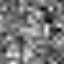

In [16]:
class TinyBevEncode(nn.Module):
    def __init__(self, inC, outC):
        super().__init__()
        self.conv1 = nn.Conv2d(inC, 32, 3, stride=2, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, stride=2, padding=1)
        self.up = nn.Sequential(
            nn.Upsample(scale_factor=4, mode='bilinear', align_corners=True),
            nn.Conv2d(64, outC, 1),
        )

    def forward(self, x):
        x1 = F.relu(self.conv1(x))
        x2 = F.relu(self.conv2(x1))
        out = self.up(x2)
        return x1, x2, out

bev_encoder = TinyBevEncode(inC=4, outC=1)
bev_in = torch.randn(2, 4, 64, 64)
x1, x2, bev_logits = bev_encoder(bev_in)
print('bev_in =', tuple(bev_in.shape))
print('after conv1 =', tuple(x1.shape))
print('after conv2 =', tuple(x2.shape))
print('bev_logits =', tuple(bev_logits.shape))
display(to_uint8_image(bev_logits[0, 0].detach().numpy()))

## 16. 监督标签 binimg 生成逻辑拆解

对应源码位置：`src/data.py::get_binimg`

训练标签不是逐像素从图像上人工画出来的，而是从 3D 标注框出发生成的 BEV 占据图：

1. 把 3D box 从全局坐标系变到当前 ego 坐标系
2. 取 box 底面四个点
3. 把这四个点映射到 BEV 栅格索引
4. 用多边形填充得到 `binimg`

下面用手写矩形框模拟这个 rasterization 过程。

mask shape = (200, 200) foreground pixels = 153


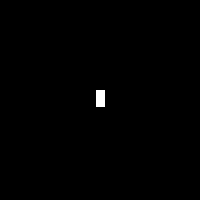

In [17]:
def polygon_mask(vertices, xbound, ybound, step=0.5):
    xs = np.arange(xbound[0], xbound[1], step)
    ys = np.arange(ybound[0], ybound[1], step)
    grid_x, grid_y = np.meshgrid(xs, ys, indexing='ij')
    mask = np.zeros_like(grid_x, dtype=np.float32)
    min_x, max_x = vertices[:, 0].min(), vertices[:, 0].max()
    min_y, max_y = vertices[:, 1].min(), vertices[:, 1].max()
    mask[(grid_x >= min_x) & (grid_x <= max_x) & (grid_y >= min_y) & (grid_y <= max_y)] = 1.0
    return mask

box_bottom = np.array([
    [-5.0, -2.0],
    [-5.0,  2.0],
    [ 3.0,  2.0],
    [ 3.0, -2.0],
])
mask = polygon_mask(box_bottom, grid_conf['xbound'][:2], grid_conf['ybound'][:2], step=0.5)
print('mask shape =', mask.shape, 'foreground pixels =', int(mask.sum()))
display(to_uint8_image(mask))

## 17. 损失函数、IoU 与单步训练闭环

对应源码位置：`src/tools.py::SimpleLoss`, `src/tools.py::get_batch_iou`, `src/train.py`

训练时：

- 模型输出的是 logits，不是概率
- 损失用 `BCEWithLogitsLoss`
- `pos_weight` 用来平衡 BEV 中前景车体像素稀少的问题
- IoU 统计时，再把 logits 用阈值 0 转成二值预测

下面先做一个最小损失和 IoU 示例，再做一次真实的 `forward -> backward -> clip_grad_norm -> step` 闭环。

In [18]:
pred_logits = torch.tensor([[[[0.2, -1.0], [2.0, 0.7]]]])
target_mask = torch.tensor([[[[1.0, 0.0], [1.0, 0.0]]]])
loss_fn = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([2.13]))
loss_value = loss_fn(pred_logits, target_mask)
pred_binary = pred_logits > 0
intersect = (pred_binary & target_mask.bool()).sum().item()
union = (pred_binary | target_mask.bool()).sum().item()
iou = intersect / union
print('loss =', float(loss_value.detach()))
print('intersect =', intersect, 'union =', union, 'iou =', iou)

simple_model = nn.Sequential(
    nn.Conv2d(4, 8, 3, padding=1),
    nn.ReLU(),
    nn.Conv2d(8, 1, 1),
)
opt = torch.optim.Adam(simple_model.parameters(), lr=1e-3)
mini_input = torch.randn(2, 4, 32, 32)
mini_target = torch.randint(0, 2, (2, 1, 32, 32)).float()
opt.zero_grad()
mini_pred = simple_model(mini_input)
mini_loss = loss_fn(mini_pred, mini_target)
mini_loss.backward()
grad_norm = torch.nn.utils.clip_grad_norm_(simple_model.parameters(), max_norm=5.0)
opt.step()
print('mini_pred shape =', tuple(mini_pred.shape))
print('mini_loss =', float(mini_loss.detach()))
print('grad_norm =', float(grad_norm))

loss = 0.7402100563049316
intersect = 2 union = 3 iou = 0.6666666666666666
mini_pred shape = (2, 1, 32, 32)
mini_loss = 1.1930022239685059
grad_norm = 0.5019484758377075


## 18. 训练循环中的日志、验证与权重保存

对应源码位置：`src/train.py`

真实训练循环除了前向和反向，还做了四件事：

- 记录 loss、IoU、step time
- 按固定频率做验证集评估
- 在验证点保存权重
- 在 `train()` / `eval()` 间切换模型模式

下面用一个伪 DataLoader 跑一个缩小版循环，把这些结构保留住。

In [19]:
fake_loader = [(torch.randn(2, 4, 32, 32), torch.randint(0, 2, (2, 1, 32, 32)).float()) for _ in range(3)]
train_model = nn.Sequential(nn.Conv2d(4, 8, 3, padding=1), nn.ReLU(), nn.Conv2d(8, 1, 1))
train_opt = torch.optim.Adam(train_model.parameters(), lr=1e-3)
train_loss_fn = nn.BCEWithLogitsLoss()
val_every = 2
counter = 0

for epoch in range(1):
    train_model.train()
    for feat, label in fake_loader:
        counter += 1
        train_opt.zero_grad()
        pred = train_model(feat)
        loss = train_loss_fn(pred, label)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(train_model.parameters(), 5.0)
        train_opt.step()
        print(f'train step={counter} loss={loss.item():.4f}')
        if counter % val_every == 0:
            train_model.eval()
            with torch.no_grad():
                val_pred = train_model(feat)
                val_loss = train_loss_fn(val_pred, label)
            print(f'  val step={counter} val_loss={val_loss.item():.4f}')
            save_path = project_root / f'mock_model_step_{counter}.pt'
            torch.save(train_model.state_dict(), save_path)
            print('  saved to', save_path.name)
            train_model.train()

train step=1 loss=0.7028
train step=2 loss=0.7025
  val step=2 val_loss=0.7020
  saved to mock_model_step_2.pt
train step=3 loss=0.7073


## 19. 几何链路可视化：Lidar 投影、BEV 标签与预测对比

对应源码位置：`src/explore.py`

`explore.py` 的作用不是训练，而是排查几何链路。典型检查有三类：

- 图像平面：点是否投影到了正确位置
- BEV 平面：点云、标签和预测是否空间对齐
- 多相机 frustum：不同相机是否共同覆盖了正确的区域

这里不依赖真实 lidar，而是用伪点和伪热图模拟这种可视化检查。

图像投影点 =
 [[ 30  40]
 [ 80  60]
 [120  90]
 [150  30]]
BEV 点云点 =
 [[-20 -10]
 [  0   5]
 [ 15  18]
 [ 30 -12]]


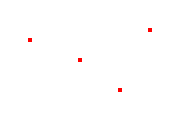

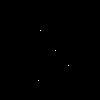

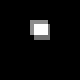

In [20]:
img_canvas = np.ones((120, 180, 3), dtype=np.float32)
img_points = np.array([[30, 40], [80, 60], [120, 90], [150, 30]])
for x, y in img_points:
    img_canvas[max(0, y-2):y+2, max(0, x-2):x+2] = np.array([1.0, 0.0, 0.0])

bev_points = np.array([[-20, -10], [0, 5], [15, 18], [30, -12]])
bev_canvas = np.zeros((100, 100), dtype=np.float32)
for x, y in bev_points:
    px = int(x + 50)
    py = int(y + 50)
    if 0 <= px < 100 and 0 <= py < 100:
        bev_canvas[px, py] = 1.0

bev_label = np.zeros((80, 80), dtype=np.float32)
bev_pred = np.zeros((80, 80), dtype=np.float32)
bev_label[20:35, 30:48] = 1.0
bev_pred[24:40, 34:50] = 0.8

print('图像投影点 =\n', img_points)
print('BEV 点云点 =\n', bev_points)
display(to_uint8_image(img_canvas))
display(to_uint8_image(bev_canvas))
display(to_uint8_image(bev_label + bev_pred))

## 20. 端到端最小实验：从一批数据跑完整个 LSS 前向与反向

这一节不直接依赖仓库里的完整 EfficientNet 主干，而是用一套“最小 LSS”把同样的主路径串起来：

1. 输入一批多相机图像
2. 预测深度分布和语义特征
3. Lift 成 frustum feature
4. 用几何模板生成 ego 点
5. Splat 到 BEV
6. 输出 logits
7. 计算 loss 和 IoU
8. 反向传播

它的意义不是替代原仓库模型，而是给你一个可以随时拿来插断点、查形状、看梯度的调试模板。

In [21]:
class MiniLSS(nn.Module):
    def __init__(self, D=6, C=4, outC=1, final_dim=(64, 64), downsample=16):
        super().__init__()
        self.D = D
        self.C = C
        self.downsample = downsample
        self.final_dim = final_dim
        self.depth_head = TinyCamEncode(D, C)
        self.bev_head = TinyBevEncode(C, outC)

    def create_frustum(self):
        H, W = self.final_dim
        fH, fW = H // self.downsample, W // self.downsample
        ds = torch.arange(1, self.D + 1, dtype=torch.float32).view(-1, 1, 1).expand(-1, fH, fW)
        xs = torch.linspace(0, W - 1, fW).view(1, 1, fW).expand_as(ds)
        ys = torch.linspace(0, H - 1, fH).view(1, fH, 1).expand_as(ds)
        return torch.stack([xs, ys, ds], dim=-1)

    def forward(self, imgs):
        B, N, _, H, W = imgs.shape
        flat = imgs.view(B * N, 3, H, W)
        depth_logits, feat = self.depth_head(flat)
        depth = F.softmax(depth_logits, dim=1)
        frustum_feat = depth.unsqueeze(1) * feat.unsqueeze(2)
        bev = frustum_feat.mean(dim=2).view(B, N, self.C, H // 16, W // 16).mean(dim=1)
        bev = F.interpolate(bev, size=(H, W), mode='bilinear', align_corners=True)
        _, _, logits = self.bev_head(bev)
        return {
            'depth_logits': depth_logits,
            'depth': depth,
            'frustum_feat': frustum_feat,
            'bev_feat': bev,
            'logits': logits,
            'frustum': self.create_frustum(),
        }

mini_lss = MiniLSS(final_dim=(64, 64))
mini_imgs = torch.randn(2, 3, 3, 64, 64)
mini_targets = torch.randint(0, 2, (2, 1, 64, 64)).float()
mini_out = mini_lss(mini_imgs)
mini_loss = loss_fn(mini_out['logits'], mini_targets)
mini_lss.zero_grad()
mini_loss.backward()
mini_iou = (((mini_out['logits'] > 0) & mini_targets.bool()).sum().item() /
            ((mini_out['logits'] > 0) | mini_targets.bool()).sum().item())

for key, value in mini_out.items():
    if isinstance(value, torch.Tensor):
        print(f'{key:>12} -> {tuple(value.shape)}')
print('loss =', float(mini_loss))
print('iou =', mini_iou)

depth_logits -> (6, 6, 4, 4)
       depth -> (6, 6, 4, 4)
frustum_feat -> (6, 4, 6, 4, 4)
    bev_feat -> (2, 4, 64, 64)
      logits -> (2, 1, 64, 64)
     frustum -> (6, 4, 4, 3)
loss = 1.067405343055725
iou = 0.500732421875


/tmp/ipykernel_1504801/3299460434.py:50: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  print('loss =', float(mini_loss))
